In [1]:
import jets
import jets.metrics as metrics

In [2]:
config = {
    'exp_name': 'test',
    'visual': {
        'fields': ['q', 'v'],
        'spectra': ['z', 'e'],
        'means' : ['z_mean', 'e_mean'],
    },
    'atmosphere': {
        'n_grid': 256, 
        'params': {
            'initial': 'zero', 
            'forcing': 'norm',
            'p': 2,
            'nu': 16 * 4e-8, 
            'r': 0.01,
            'epsilon': 1.0,
            'kf': 16,
            'dkf': 2,
        }
    },
    'integrator': {
        'method': 'rk4',
        'interval': 1,
        'n_points': 100,
    },
}

model = jets.Driver()
model.setup(**config)
model.start()
print(model.descript())

def check_saturation(climate):
    if len(climate['t'])<=2:
        return False, None
    t, z_mean = climate['t'][1::], climate['z_mean'][1::]
    z_params, z_found = metrics.find_saturation(t, z_mean, crit=1)
    if z_found:
        metrics.plot_saturation(t, z_mean, z_params, 'z_mean')
        print(f"found t_sat: {z_found}")
        return True, z_params
    else:
        return False, None

[meta]
model = qgc-1
type = quasi-geostrophic
coord = cartesian
approach = spectral-1

[atmosphere]
initial = zero
forcing = norm
initial_seed = 42
forcing_seed = 42
p = 2
beta = 0.0
nu = 6.4e-07
r = 0.01
kappa = 0.0
epsilon = 1.0
kf = 16
dkf = 2
sigma = 1.0
forcing_dt = 0.01

[integrator]
method = rk4
interval = 1
n_points = 100




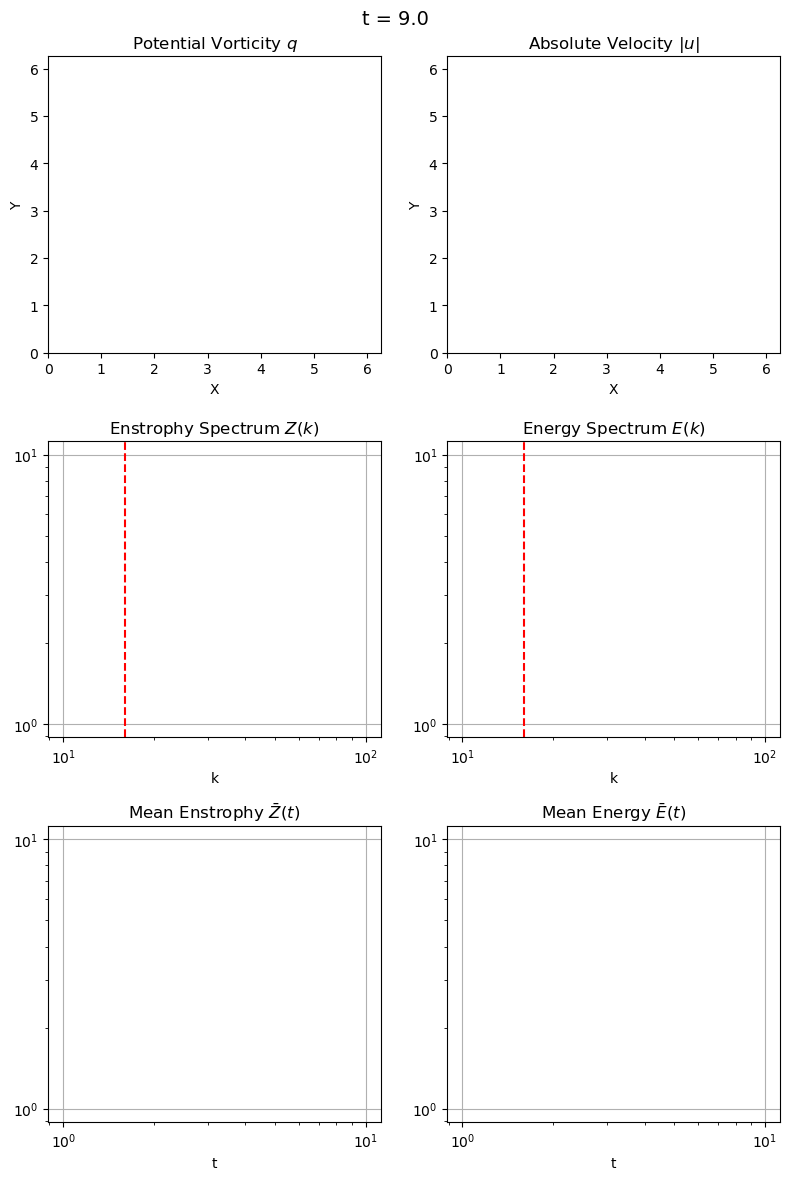

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:23<00:00,  2.36s/it]


In [3]:
data = model.run(10, show=True), #metrics=check_saturation, logtime=True, tau=2)

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

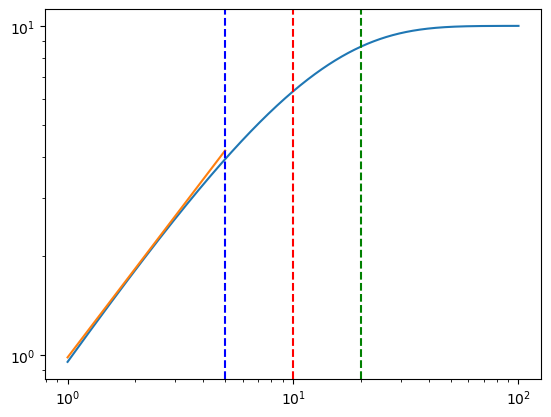

In [42]:
t_sat = 10
E_sat = 10.0
log_t = np.log(t_sat) + np.linspace(np.log(0.1), np.log(10), 1000)
t = np.exp(log_t)
E = E_sat * (1 - np.exp(- t/t_sat))
E_lin = 0.78*E_sat * (t/t_sat)**(0.9)

plt.loglog(t, E)
plt.loglog(t[:350:], E_lin[:350:])
plt.axvline(t_sat, color='r', linestyle='--')
plt.axvline(0.5*t_sat, color='b', linestyle='--')
plt.axvline(2*t_sat, color='g', linestyle='--')